## **Name:** Aaditi Parab
## **Computing ID:** ID

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Lab 4: Unsupervised Learning (100 Points)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1CqzvUaaggcKdCvVi6dS9BAeB9nuQl_Ns?usp=sharing)

In this lab, we will implement 2 models in the unsupervised learning family **K-means clustering** and **Principal Component Analysis (PCA)**.

You will utilize the skills you have gained over the semester to build, explore, and evaluate your models. As always, you will be graded on your model building and interpretation of  results rather than specific performance.

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*h-lAg5H-ZNDRXxX2.png)

# **Part 1: K-Means Clustering (50 points)**

## For Part 1, you will pick from the following preloaded datasets:



In [62]:
pokemon_df = pd.read_csv("https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv")

In [63]:
# Load Fashion MNIST data
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

**Another option open to you, if you wish, is to  utilize a dataset of your choice (including your final project dataset).**


In a text cell, answer the following exploratory questions and support your observations with any code, if needed.

## **Question 1 (5 points):**
## Read in your dataset as a Pandas DataFrame. Show the first 5 rows. How many rows and columns do you have?

## What are your features and their datatypes?


In [64]:
pokemon_df = pd.read_csv("https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv")
print(pokemon_df.head())
print(pokemon_df.shape)
print(pokemon_df.dtypes)


   #                   Name Type 1  Type 2  Total  HP  Attack  Defense  \
0  1              Bulbasaur  Grass  Poison    318  45      49       49   
1  2                Ivysaur  Grass  Poison    405  60      62       63   
2  3               Venusaur  Grass  Poison    525  80      82       83   
3  3  VenusaurMega Venusaur  Grass  Poison    625  80     100      123   
4  4             Charmander   Fire     NaN    309  39      52       43   

   Sp. Atk  Sp. Def  Speed  Generation  Legendary  
0       65       65     45           1      False  
1       80       80     60           1      False  
2      100      100     80           1      False  
3      122      120     80           1      False  
4       60       50     65           1      False  
(800, 13)
#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Ge

    **There is a total of...800 rows, 13 columns**
    features and datatypes:
number(#)      int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool


## **Question 2 (5 points):**
## Identify what percentage of each column has missing values and display this information (column name, percentage values missing) in a DataFrame.

## Then, fill in any missing values using any method appropriate for each column's data type and values.

In [65]:
pokemon_df = pokemon_df.replace(['null', '','-'], np.nan) 
percent_missing_df = pd.DataFrame(columns = ['column_name','percent_missing'])

for col in pokemon_df.columns:
    null_count=pokemon_df[col].isnull().sum() #count the number of nans
    percentage=null_count/800
    row_to_add = {'column_name': col, 'percent_missing': percentage}
    percent_missing_df.loc[len(percent_missing_df)] = row_to_add
print(percent_missing_df)

pokemon_df["Type 2"] = pokemon_df["Type 2"].fillna("None") 
    

    
    


   column_name  percent_missing
0            #           0.0000
1         Name           0.0000
2       Type 1           0.0000
3       Type 2           0.4825
4        Total           0.0000
5           HP           0.0000
6       Attack           0.0000
7      Defense           0.0000
8      Sp. Atk           0.0000
9      Sp. Def           0.0000
10       Speed           0.0000
11  Generation           0.0000
12   Legendary           0.0000


## **Question 3 (5 points):**
## Identify columns in your DataFrame that need to be encoded and use the proper encoder for each feature to transform your categorical data into numerical features.

## In a sentence per each encoded feature, justify your choice in encoder and why you utilized it

In [66]:
from sklearn.preprocessing import OneHotEncoder

pokemon_df = pokemon_df.drop(columns = ['#','Name']) #drop irrelevant columns

#encode type 1 feature
type1_encoder = OneHotEncoder(sparse_output=False)
encoded_type1 = type1_encoder.fit_transform(pokemon_df[['Type 1']])
encoded_type1_df=pd.DataFrame(encoded_type1, columns=type1_encoder.get_feature_names_out(['Type 1']))

#encode type 2 feature
type2_encoder = OneHotEncoder(sparse_output=False)
encoded_type2 = type2_encoder.fit_transform(pokemon_df[['Type 2']])
encoded_type2_df=pd.DataFrame(encoded_type2, columns=type2_encoder.get_feature_names_out(['Type 2']))

#convert legendary feature column to int- binary encoding
pokemon_df['Legendary']=pokemon_df['Legendary'].astype(int)

#put final df together
num_df = pokemon_df.drop(columns = ['Type 1', 'Type 2', 'Legendary']).reset_index(drop=True)

encoded_poke_df = pd.concat([num_df, encoded_type1_df, encoded_type2_df], axis=1)

**I encoded Feature A with XYZ encoding because...**
'#' and Name: dropped because they are identifiers, not features
numeric features: encoding not needed, already numeric
type1 & type2: one hot encoding because these are categorical features with no order
Legendary: binary because yes/no


## **Question 4 (5 points):**
## Finally, identify your numerical columns and apply both standardization and normalization.

## Display each numerical column name and its minimum and maximum values in a DataFrame after these 2 processes.

## In 2 to 3 sentences, summarize the DataFrame and the effects of your choice in standardization and normalization had on your numerical features? Why would scaling your data be beneficial for unsupervised learning?

In [67]:
from sklearn.preprocessing import StandardScaler, Normalizer

nonscaled = pd.DataFrame({
    "Column Name": encoded_poke_df.columns,
    "Min": encoded_poke_df.min().values,
    "Max": encoded_poke_df.max().values
})

print('min/max before scaling and normalizing:')
display(nonscaled)

scaler = StandardScaler()
scaled = scaler.fit_transform(encoded_poke_df)
scaleddf = pd.DataFrame(scaled, columns=encoded_poke_df.columns) 

normalizer = Normalizer()
normalized = normalizer.fit_transform(scaleddf)
final_df = pd.DataFrame(normalized, columns=encoded_poke_df.columns)


#display(final_df)

numericdf = pd.DataFrame({
    "Column Name": final_df.columns,
    "Scaled and Normalized Min": final_df.min().values,
    "Scaled and Normalized Max": final_df.max().values
})

print('min/max after scaling and normalizing:')
numericdf




min/max before scaling and normalizing:


,Column Name,Min,Max
0,Total,180.0,780.0
1,HP,1.0,255.0
2,Attack,5.0,190.0
3,Defense,5.0,230.0
4,Sp. Atk,10.0,194.0
5,Sp. Def,20.0,230.0
6,Speed,5.0,180.0
7,Generation,1.0,6.0
8,Type 1_Bug,0.0,1.0
9,Type 1_Dark,0.0,1.0


min/max after scaling and normalizing:


,Column Name,Scaled and Normalized Min,Scaled and Normalized Max
0,Total,-0.384981,0.423212
1,HP,-0.386899,0.823144
2,Attack,-0.419520,0.488522
3,Defense,-0.406217,0.638373
4,Sp. Atk,-0.367030,0.501281
5,Sp. Def,-0.396694,0.592223
6,Speed,-0.446041,0.656317
7,Generation,-0.417884,0.433313
8,Type 1_Bug,-0.099666,0.848306
9,Type 1_Dark,-0.065132,0.941335


**The methods I used to standardize and normalize my data caused the values of my data to range...**
Before scaling and normalizing, the data had high ranges and the ranges varied greatly between the different features. After scaling, all values are between -1 and 1. 

**I think scaling your data is helpful for unsupervised learning because scaled data...**
When features have different scales, the model may strongly weigh features with higher ranges compared to those with lower ranges, causing bias and misleading results. Scaling will ensure that all features are weighed equally in PCA and clustering. 

## **Question 5 (7 points):**
## Create a function to instantiate K-Means Clustering model with a user inputted parameter for "k" number clusters. Also tune a minimum of 3 hyperparameters of your choice, referencing documentation as necessary:
* https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  


## Fit your model to your data, adding your predictions in a column of your DataFrame called cluster. Return this new dataframe in your function. Call your function on your data with k = 3.

In [109]:
from sklearn.cluster import KMeans

def k_means_func(mydataframe, kvalue):
    k_means_model = KMeans(n_clusters=kvalue, init = 'random', n_init = 20, max_iter=400, random_state=3001)
    
    clusters = k_means_model.fit_predict(mydataframe)
    
    result_df = mydataframe.copy()
    result_df['cluster'] = clusters
    
    return result_df

resultsdf=k_means_func(final_df, 3)

display(resultsdf)
'''
k5results=k_means_func(final_df, 5)

cluster_sizes = k5results['cluster'].value_counts()
print(cluster_sizes)'''




    
    
    

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Type 1_Bug,Type 1_Dark,...,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water,cluster
0,-0.151715,-0.147655,-0.143660,-0.123817,-0.037143,-0.038550,-0.124493,-0.217398,-0.047721,-0.031186,...,-0.033223,-0.020730,-0.149980,-0.011011,0.737249,-0.032218,-0.020730,-0.026119,-0.020730,0
1,-0.040655,-0.058746,-0.084864,-0.056333,0.035550,0.047142,-0.046148,-0.226621,-0.049745,-0.032509,...,-0.034633,-0.021609,-0.156343,-0.011478,0.768527,-0.033585,-0.021609,-0.027227,-0.021609,0
2,0.118489,0.066512,0.014608,0.046433,0.131336,0.159643,0.063782,-0.221168,-0.048548,-0.031727,...,-0.033799,-0.021089,-0.152581,-0.011202,0.750035,-0.032777,-0.021089,-0.026572,-0.021089,2
3,0.227799,0.060535,0.093102,0.226853,0.216284,0.248717,0.058049,-0.201291,-0.044185,-0.028875,...,-0.030762,-0.019194,-0.138868,-0.010195,0.682626,-0.029831,-0.019194,-0.024184,-0.019194,2
4,-0.214935,-0.242299,-0.170099,-0.202234,-0.080108,-0.160926,-0.023061,-0.286005,-0.062780,-0.041028,...,-0.043708,-0.027272,0.211624,-0.014485,-0.043051,-0.042386,-0.027272,-0.034362,-0.027272,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.160039,-0.087812,0.075325,0.284345,0.096708,0.326738,-0.073227,0.187560,-0.035748,-0.023362,...,-0.024888,-0.015529,-0.112352,-0.008248,-0.024514,-0.024135,-0.015529,-0.019566,-0.015529,2
796,0.246851,-0.084314,0.278978,0.129622,0.297836,0.153040,0.160499,0.180088,-0.034324,-0.022431,...,-0.023897,-0.014910,-0.107876,-0.007920,-0.023537,-0.023174,-0.014910,-0.018787,-0.014910,2
797,0.147156,0.045033,0.102245,-0.047523,0.252506,0.223497,0.006346,0.172461,-0.032870,-0.021481,...,-0.022885,-0.014279,-0.103308,-0.007584,-0.022541,-0.022192,-0.014279,-0.017991,-0.014279,2
798,0.226641,0.046701,0.277055,-0.049282,0.329711,0.231773,0.044784,0.178847,-0.034087,-0.022276,...,-0.023732,-0.014808,-0.107133,-0.007865,-0.023375,-0.023014,-0.014808,-0.018657,-0.014808,2


"\nk5results=k_means_func(final_df, 5)\n\ncluster_sizes = k5results['cluster'].value_counts()\nprint(cluster_sizes)"

## **Question 6 (5 points):**
## Write code to plot your predicted clusters, with different colors for different cluster numbers. Apply this code to the predictions you obtained in Question 5 and describe the output.

## In a minimum of 3 sentences, based on all the information you have, describe why k = 3 seems like a reasonable or unreasounable amount of clusters for your data.

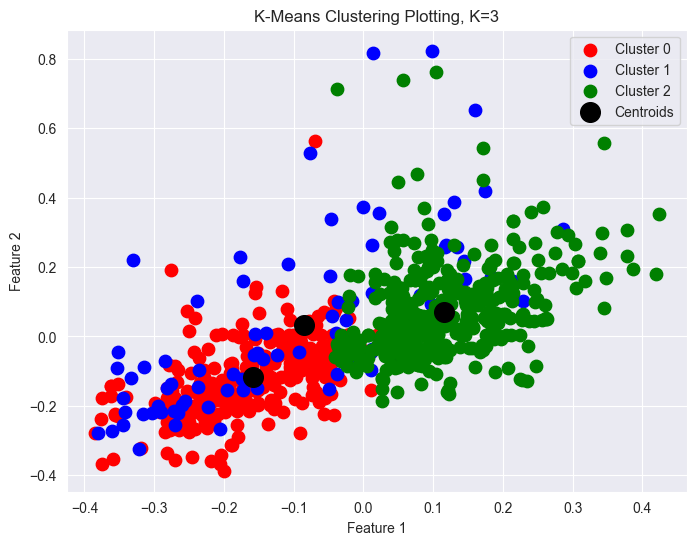

In [71]:

from sklearn.cluster import KMeans

def k_means_func(mydataframe, kvalue):
    k_means_model = KMeans(
        n_clusters=kvalue,
        init='random',
        n_init=20,
        max_iter=400,
        random_state=3001
    )
    clusters = k_means_model.fit_predict(mydataframe)

    result_df = mydataframe.copy()
    result_df['cluster'] = clusters #new df including clusters
    
    return result_df, k_means_model #return both the df and model

resultsdf, kmeans = k_means_func(final_df, 3) #call function
x = final_df.values                     
y_kmeans = resultsdf["cluster"].values  

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# cluster 0
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1],
            s=80, c='red', label='Cluster 0')
# cluster 1
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1],
            s=80, c='blue', label='Cluster 1')
# cluster 2
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1],
            s=80, c='green', label='Cluster 2')
# centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.title("K-Means Clustering Plotting, K=3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()




**Because the predicted clusters show XYZ, I believe k=3 is/is not a reasonable choice...**
After plotting the clusters from the K-means clustering model, k=3 is not a reasonable choice because the clusters are not very distinct. Cluster 1 in particular has points that are highly dispersed and overlap with the other two clusters, indicating that these points may not be grouped together in the best version of this model. The lack of clear clusters show that a different k value would be a more reasonable choice. 

## **Question 7 (8 points):**
## Plot an elbow plot for your clustering model with any metric of your choice and pick an optimal k value.

## Then, utilize the optimal k to tune at least 3 K-Means Clustering models by varying the hyperparameters. For each model, you will use the optimal k number of clusters you identified in your elbow plot but vary at least 3 other hyperparameters. Plot your predicted clusters differentiated by color.

used an elbow plot and it didnt really have a strong elbow point so then used a silhouette score which determined that the optimal k value was very high (10). then after manually plotting the three tuned models with different options for k values, k=4 or 5 results in the most distinctly grouped clusters. 

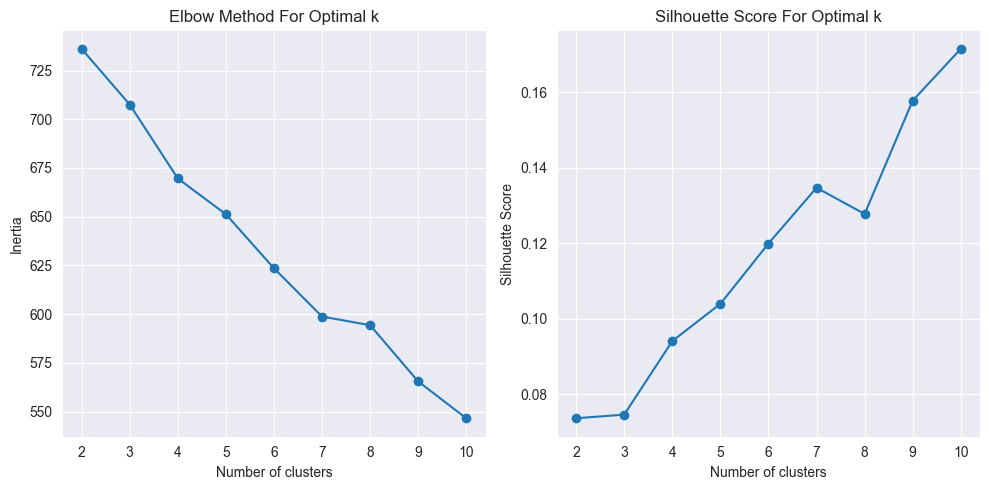

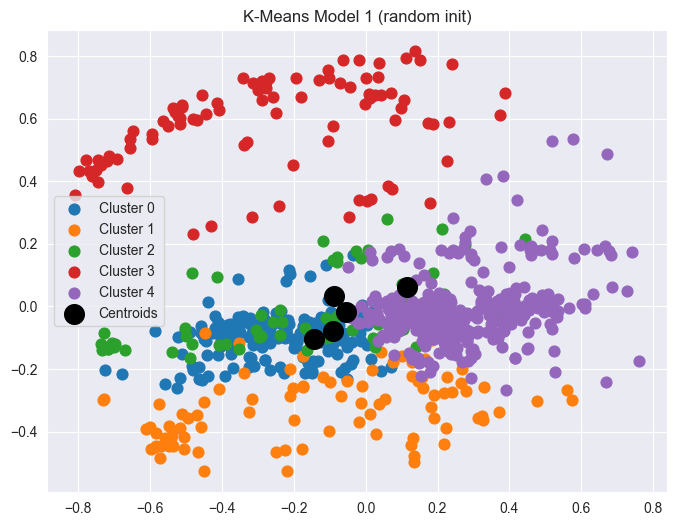

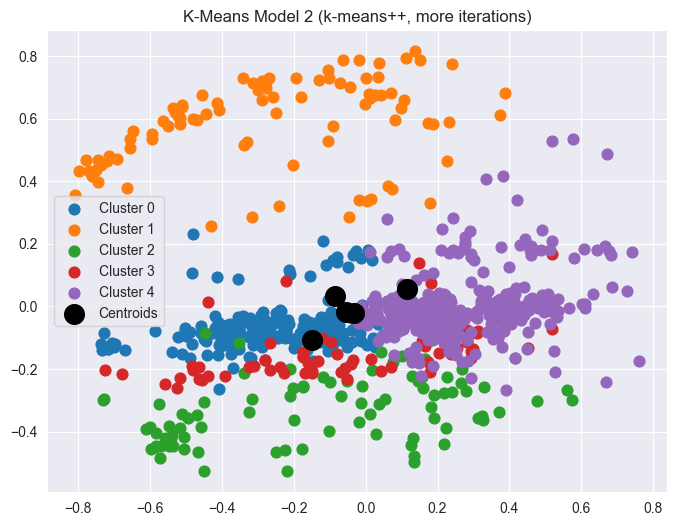

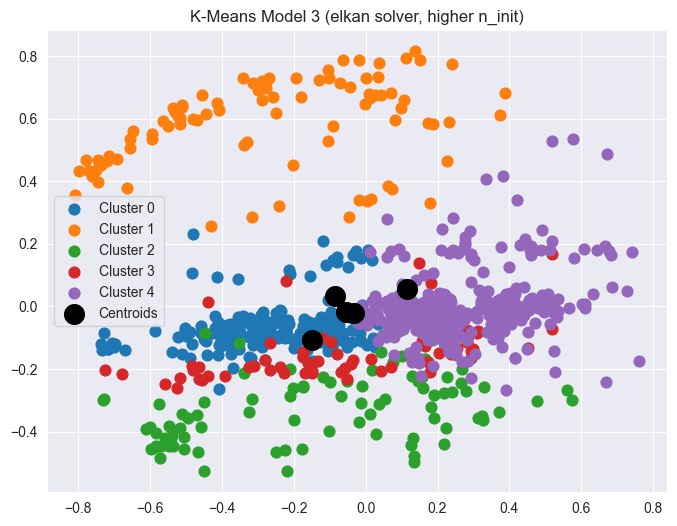

In [104]:
from sklearn.metrics import silhouette_score

#---------------------------------------------------ELBOW PLOT
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(final_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

#---------------------------------------------------SIL SCORE
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(final_df)
    silhouette_scores.append(silhouette_score(final_df, kmeans.labels_))

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

#---------------------------------------------------MODELS
from sklearn.decomposition import PCA

# reduce to 2 components
pca = PCA(n_components=2)
pca_final_df = pca.fit_transform(final_df)

k_num = 5
#-----------------------------model 1
kmeans1 = KMeans(
    n_clusters=k_num,
    init='random',
    n_init=10,
    max_iter=400,
    random_state=3001
)
labels1 = kmeans1.fit_predict(final_df)
# plotting
plt.figure(figsize=(8,6))
for c in range(k_num):
    plt.scatter(pca_final_df[labels1 == c, 0],
                pca_final_df[labels1 == c, 1],
                s=60,
                label=f'Cluster {c}')

plt.scatter(kmeans1.cluster_centers_[:, 0], 
            kmeans1.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')

plt.title("K-Means Model 1 (random init)")
plt.legend()
plt.show()
#----------------------------model 2
kmeans2 = KMeans(
    n_clusters=k_num,
    init='k-means++',
    n_init=20,
    max_iter=600,
    tol=1e-5,
    random_state=42
)

labels2 = kmeans2.fit_predict(final_df)
plt.figure(figsize=(8,6))
for c in range(k_num):
    plt.scatter(pca_final_df[labels2 == c, 0],
                pca_final_df[labels2 == c, 1],
                s=60,
                label=f'Cluster {c}')

plt.scatter(kmeans2.cluster_centers_[:, 0], 
            kmeans2.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')

plt.title("K-Means Model 2 (k-means++, more iterations)")
plt.legend()
plt.show()

#----------------------------model 3
kmeans3 = KMeans(
    n_clusters=k_num,
    init='k-means++',  
    n_init=50,
    max_iter=1000,
    algorithm='elkan',  
    random_state=42
)

labels3 = kmeans3.fit_predict(final_df)

#Plotting
plt.figure(figsize=(8,6))
for c in range(k_num):
    plt.scatter(pca_final_df[labels3 == c, 0],
                pca_final_df[labels3 == c, 1],
                s=60,
                label=f'Cluster {c}')
plt.scatter(kmeans3.cluster_centers_[:, 0], 
            kmeans3.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.title("K-Means Model 3 (elkan solver, higher n_init)")
plt.legend()
plt.show()



## In a minimum of 5 sentences, reflect on your tuned models. Write what you judge the optimal amount of clusters to be and why. How do the plots of your clusters change with tuning specific parameters? Do your results make sense?

**I picked a k of X clusters because...**

**Yes. My tuned models make sense because...**
Different methods resulted in different optimal values for k. Using an elbow plot did not show a very clear bend so I also plotted silhouette score for the different k-values. Plotting the silhouette scores suggested a very high optimal k (around 10), but plotting the models with k=10 did not result in clear meaningful clusters. After manually plotting the three tuned models with different k values, the most distinct clusters occured at k=4 or k=5, rather than the values suggested by the silhouette score plot. I chose to use k=5 clusters as this resulted in clearest groups. Tuning parameters such as init method, max_iter, n_init, and algorithm slightly changed the closeness and location of the clusters but the overall shape was similar for all three models. These results make sense as the Pokemon dataset contains encoded categorical data which may not cluster naturally. 

## **Question 8 (10 points):**
## Now, examine the makeup of your clusters. Create plots and visualizations that may explain your initial groupings.

## You may do this by color coding your clusters by a given feature or by examining descriptive statistics of each cluster (ie: cluster 1 has an average temperature of 15 while cluster 2....)

## Write a **10 to 15 sentence** reflection on why you think your clusters have oriented the way they display. Are you clusters similar are very different in their feature makeup? Are you clusters similarly sized or are some much larger or smaller? Are there any aspects of the clusters that don't make sense when compared your original data or targets?




cluster_sizes:
0    217
1     90
2     90
3     68
4    335
Name: count, dtype: int64


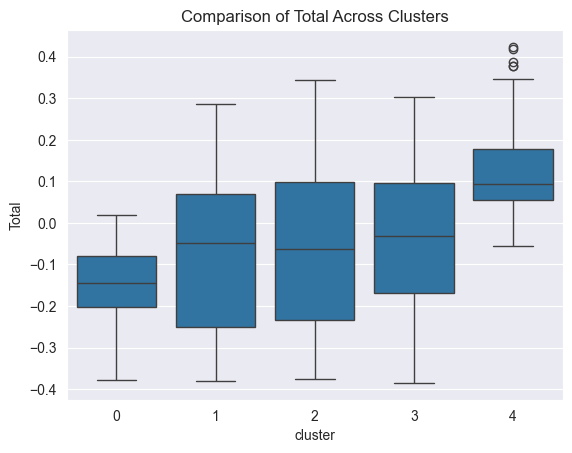

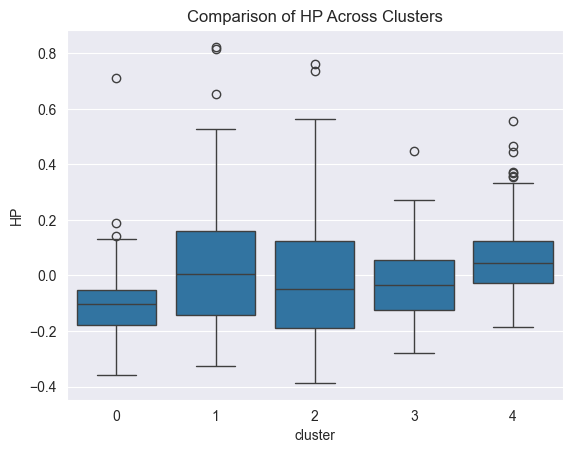

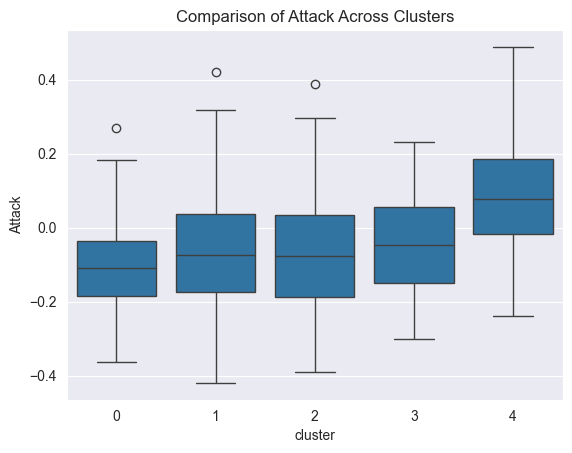

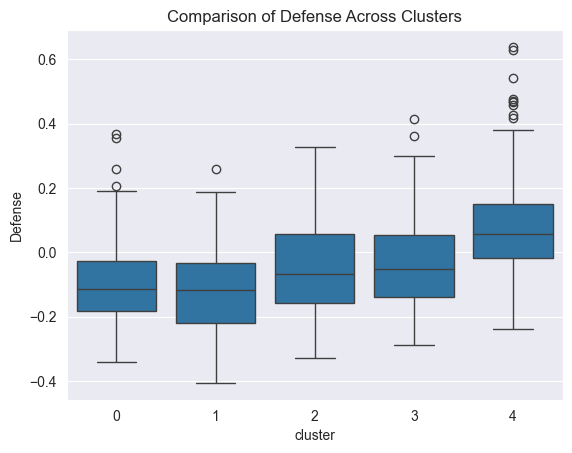

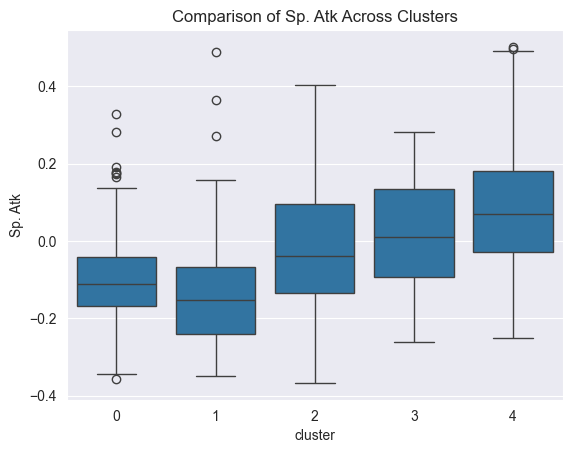

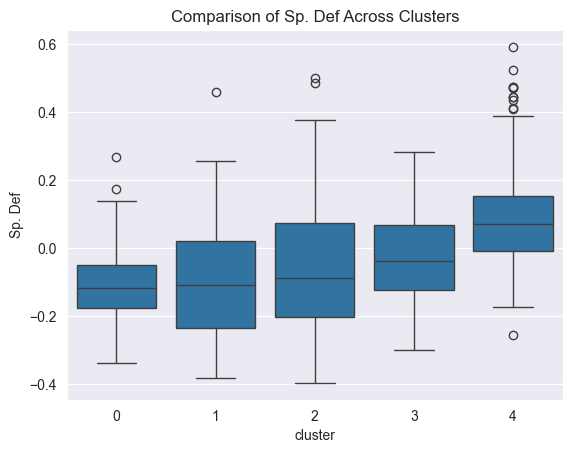

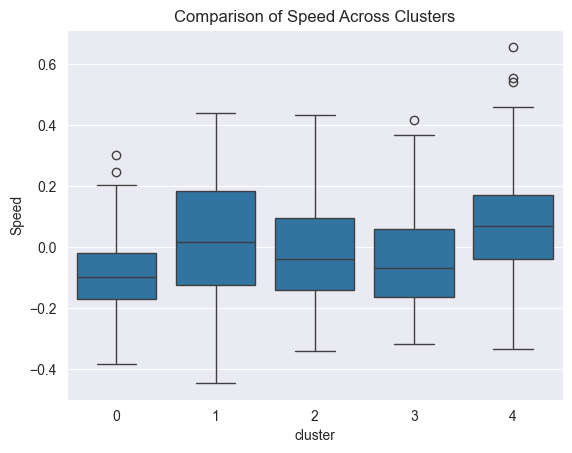

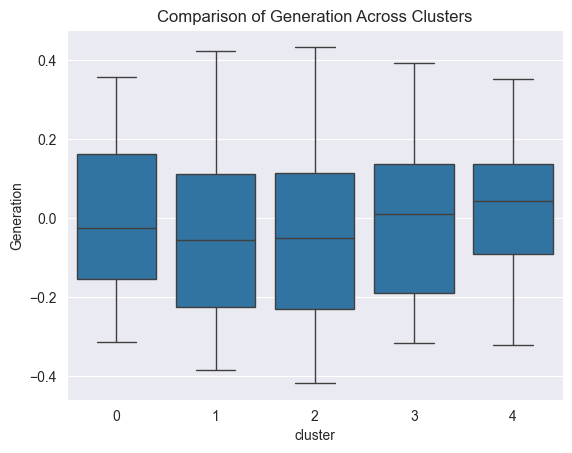

In [121]:
import seaborn as sns

##old function
'''def k_means_func(mydataframe, kvalue):
    k_means_model = KMeans(n_clusters=kvalue, init = 'random', n_init = 20, max_iter=400, random_state=3001)
    
    clusters = k_means_model.fit_predict(mydataframe)
    
    result_df = mydataframe.copy()
    result_df['cluster'] = clusters
    
    return result_df

resultsdf=k_means_func(final_df, 3)

display(resultsdf)'''

##how many points in each cluster
clusters = kmeans2.fit_predict(final_df)

cluster_size = pd.Series(clusters).value_counts().sort_index()
print('cluster_sizes:')
print(cluster_size)

#box plots for numerical features
boxplotdf = final_df.copy()
boxplotdf['cluster'] = clusters
#display(boxplotdf)

for feature in ['Total','HP','Attack', 'Defense','Sp. Atk', 'Sp. Def','Speed','Generation']:
    sns.boxplot(x='cluster', y=feature, data=boxplotdf)
    plt.title(f'Comparison of {feature} Across Clusters')
    plt.show()



**After examining my clusters, I believe the groupings make sense because....**


After examining my clusters, I believe the groupings make sense because they capture subtle distinctions in the numerical Pokemon features. The clusters slightly vary in size: most data points fall under cluster 4 (335 points), while fewer Pokemon fall under clusters 1 and 2(90 points). From box plots, clusters 1 and 2 have similar feature distributions, which suggests that these clusters both consist of Pokemons that have similar stats. Their boxplots were very similar for features: generation, attack, HP, total. Cluster 4 has the highest average values across all numerical features, corresponding to overall more powerful Pokemon. Meanwhile, clusters 0 and 1 generally have lower averages for numerical features, indicating slightly weaker Pokemon types. Overall, the clusters were not extremely different in their feature makeups. This makes sense because the data was standardized and normalized, compressing the scale of all numerical values in the dataset. The overlapping data shown in box plots explains why the clusters are somewhat distinct but not sharply separated. This observation also aligns with the fact that many different attributes contribute to Pokemon types.


# **Part 2: Principal Component Analysis (50 Points)**

## **Question 1 (15 points):**
## Fit a PCA model to a dataset if your choice. Write code to visualize the first 2 principal components and color code your groups to differentiate them.



## **Question 2 (10 points):**
## Create 2 barplots:

*   The first barplot should show the percentage variance explained by each principal component

* The first barplot should show the **cumulative** percentage variance explained by each principal component. Add a horizontal red line on this graph depicting when the cumulative variance has hit 80%.


## Write 2 to 3 sentences on how many components explain 80% of the variability in your dataset. Are the results surprising given how much variance is in (or not in) your data? What features would you consider dropping based on your results and why?


**It tales N components to explain...**

**I would consider dropping...**

## **Question 3 (25 points):**
## Write **3 paragraphs**, supported by code and exploratory analysis, explaining and exploring the groupings you see in your data. Utilize data features to justify why the components that explain so much of the variance in your data are reasonable. Explain what kind of applications or decision making your analysis can help support.

## You may choose to explore beyond simply the first 2 principal components if you wish.



**The principal components show...**

**The PCs responsible for explaining the majority of variance...**

**These results can be used for...**

### Honor Pledge

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.